# Payams (admin3) - 2022 to 2024

Payam = unit under a county. Same three states as the county zoom: Jonglei, Unity, Upper Nile.

IPC is not at payam. Hazard can be payam. Impact proxy stays county/state.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from shapely.geometry import Point
import rasterio

%matplotlib inline

ROOT = Path(".").resolve()
if not (ROOT / "raw_data").exists():
    ROOT = Path("..").resolve()
DATA = ROOT / "raw_data"
OUT = ROOT / "eda" / "outputs" / "admin3"
OUT.mkdir(parents=True, exist_ok=True)

# same years/bbox as the county notebook so ranks are comparable
YEARS = [2022, 2023, 2024]
STATES = {"Jonglei", "Unity", "Upper Nile"}
BBOX = {"lat_min": 5.72, "lat_max": 12.24, "lon_min": 28.69, "lon_max": 35.02}
TILES = ["h20v08", "h21v08"]
MAX_POINTS = 100000


In [2]:
admin3 = gpd.read_file(DATA / "Administrative boundaries" / "ssd_admin3.geojson")
focus = admin3[admin3["adm1_name"].isin(STATES)].copy()
print("payams in Jonglei+Unity+Upper Nile:", len(focus))

def unusual_points(year):
    parts = [pd.read_parquet(DATA / "flood_masks" / "compact_unusual" / f"flood_events_{tile}_{year}.parquet", columns=["lat","lon"]) for tile in TILES]
    u = pd.concat(parts, ignore_index=True)
    m = (u.lat.between(BBOX["lat_min"], BBOX["lat_max"])) & (u.lon.between(BBOX["lon_min"], BBOX["lon_max"]))
    return u.loc[m, ["lon","lat"]].drop_duplicates().reset_index(drop=True)

all_counts = []
for year in YEARS:
    u = unusual_points(year)
    n_all = len(u)
    use = u.sample(MAX_POINTS, random_state=0) if n_all > MAX_POINTS else u
    gdf = gpd.GeoDataFrame(use, geometry=[Point(xy) for xy in zip(use.lon, use.lat)], crs="EPSG:4326")
    joined = gpd.sjoin(gdf, focus[["adm1_name","adm2_name","adm3_name","geometry"]], how="inner", predicate="within")
    c = joined.groupby(["adm1_name","adm2_name","adm3_name"]).size().reset_index(name="unusual_unique_px")
    c["year"] = year
    c["points_before_sample"] = n_all
    c["sampled_down"] = n_all > MAX_POINTS
    all_counts.append(c)
    print(year, "unique", n_all, "payams_hit", c.adm3_name.nunique())

counts = pd.concat(all_counts, ignore_index=True)
counts.to_csv(OUT / "payam_unusual_2022_2024.csv", index=False)
counts.sort_values(["year","unusual_unique_px"], ascending=[True, False]).groupby("year").head(5)


payams in Jonglei+Unity+Upper Nile: 214


2022 unique 240086 payams_hit 179


2023 unique 230384 payams_hit 183


2024 unique 242555 payams_hit 173


,adm1_name,adm2_name,adm3_name,unusual_unique_px,year,points_before_sample,sampled_down
11,Jonglei,Ayod,Pajiek,4339,2022,240086,True
124,Unity,Rubkona,Budaang,4328,2022,240086,True
119,Unity,Pariang,Biu,3811,2022,240086,True
130,Unity,Rubkona,Rubkotne,3708,2022,240086,True
135,Upper Nile,Baliet,Akotweng,3420,2022,240086,True
304,Unity,Rubkona,Budaang,6226,2023,230384,True
315,Upper Nile,Baliet,Akotweng,5547,2023,230384,True
299,Unity,Pariang,Biu,3820,2023,230384,True
310,Unity,Rubkona,Rubkotne,3748,2023,230384,True
309,Unity,Rubkona,Panhiany,2664,2023,230384,True


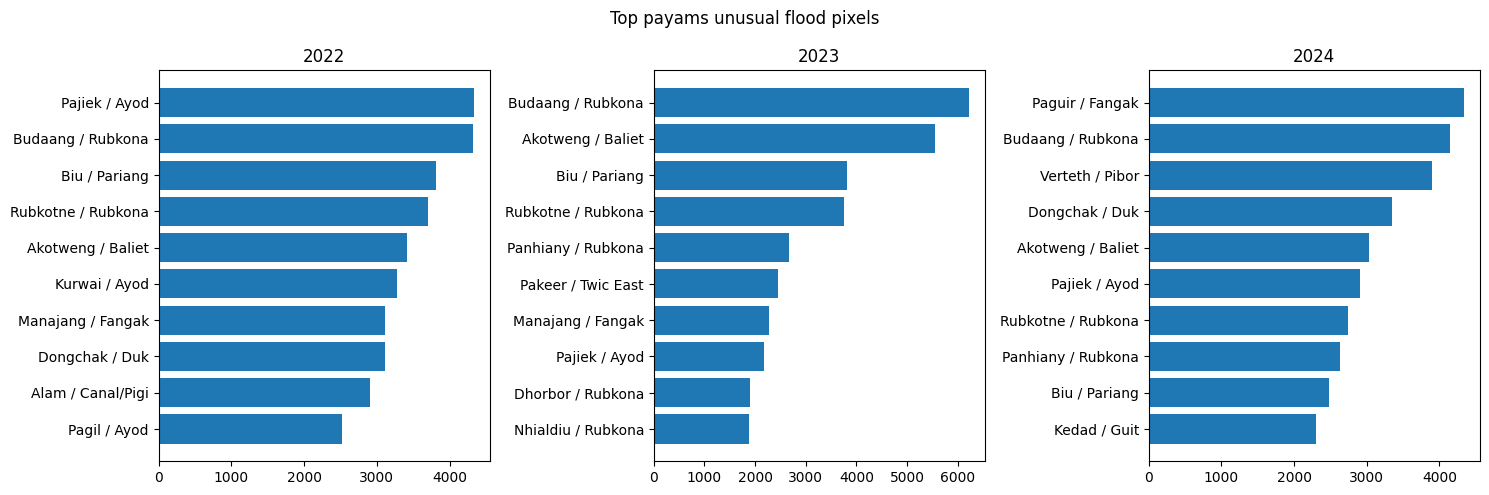

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, year in zip(axes, YEARS):
    top = counts[counts.year==year].sort_values("unusual_unique_px", ascending=False).head(10)
    labels = top["adm3_name"] + " / " + top["adm2_name"]
    ax.barh(labels[::-1], top["unusual_unique_px"][::-1])
    ax.set_title(str(year))
fig.suptitle("Top payams unusual flood pixels")
fig.tight_layout()
fig.savefig(OUT / "01_payam_top_by_year.png", dpi=140)
plt.show()


Population under unusual pixels for the top payams of 2023 (WorldPop sample). Same method can be repeated for other years if needed.

,adm1_name,adm2_name,adm3_name,n_px_used,pop_sum
6,Unity,Rubkona,Nhialdiu,1886,2384.522644
8,Unity,Rubkona,Rubkotne,3000,1884.719342
5,Unity,Rubkona,Dhorbor,1898,1534.046770
4,Unity,Rubkona,Budaang,3000,1319.615545
1,Jonglei,Fangak,Manajang,2275,1098.259865
7,Unity,Rubkona,Panhiany,2664,463.286096
0,Jonglei,Ayod,Pajiek,2174,319.998382
2,Jonglei,Twic East,Pakeer,2444,317.671159
9,Upper Nile,Baliet,Akotweng,3000,37.881550
3,Unity,Pariang,Biu,3000,29.380353


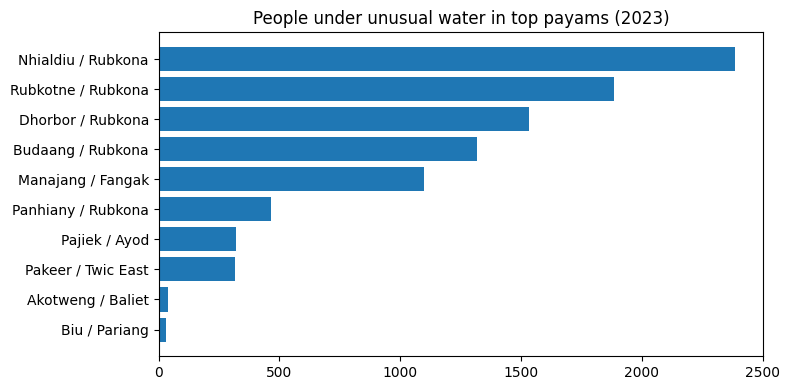

In [4]:
# pixel rank is not people. sample worldpop on the top 10 payams for 2023
YEAR = 2023
c2023 = counts[counts.year==YEAR].sort_values("unusual_unique_px", ascending=False)
top10 = set(zip(c2023.head(10).adm1_name, c2023.head(10).adm2_name, c2023.head(10).adm3_name))
u = unusual_points(YEAR)
use = u.sample(MAX_POINTS, random_state=0) if len(u) > MAX_POINTS else u
gdf = gpd.GeoDataFrame(use, geometry=[Point(xy) for xy in zip(use.lon, use.lat)], crs="EPSG:4326")
joined = gpd.sjoin(gdf, focus[["adm1_name","adm2_name","adm3_name","geometry"]], how="inner", predicate="within")
joined["key"] = list(zip(joined.adm1_name, joined.adm2_name, joined.adm3_name))
sub = joined[joined.key.isin(top10)]

rows = []
with rasterio.open(DATA / "worldpop" / f"ssd_pop_{YEAR}_CN_100m_R2025A_v1.tif") as src:
    for key, g in sub.groupby("key"):
        gg = g.sample(min(3000, len(g)), random_state=0)
        vals = np.array([v[0] for v in src.sample(zip(gg.geometry.x, gg.geometry.y))], dtype=float)
        if src.nodata is not None:
            vals[vals == src.nodata] = np.nan
        rows.append({"adm1_name": key[0], "adm2_name": key[1], "adm3_name": key[2], "n_px_used": len(gg), "pop_sum": float(np.nansum(vals))})
pop_payam = pd.DataFrame(rows).sort_values("pop_sum", ascending=False)
pop_payam.to_csv(OUT / "payam_top10_pop_on_unusual_2023.csv", index=False)
display(pop_payam)

fig, ax = plt.subplots(figsize=(8, 4))
lab = pop_payam.adm3_name + " / " + pop_payam.adm2_name
ax.barh(lab[::-1], pop_payam.pop_sum[::-1])
ax.set_title("People under unusual water in top payams (2023)")
fig.tight_layout()
fig.savefig(OUT / "02_payam_pop_on_unusual.png", dpi=140)
plt.show()
